# SVM for classification

Load IRIS dataset, check its contents:


In [1]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [2]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [3]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

1.0

Let's explore more now. 

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [ ]:
X2 = iris.data[:, :2]

mask = iris.target != 2
X2_binary = X2[mask]
y2_binary = iris.target[mask]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2_binary, y2_binary, test_size=0.2, random_state=42)
print(X_train2.shape)
print(X_test2.shape)

SVMmodel2 = SVC(kernel='linear')
SVMmodel2.fit(X_train2, y_train2)
SVMmodel2.score(X_test2, y_test2)


(80, 2)
(20, 2)


1.0

Plot scatterplots of targets 0 and 1 and check the separability of the classes:

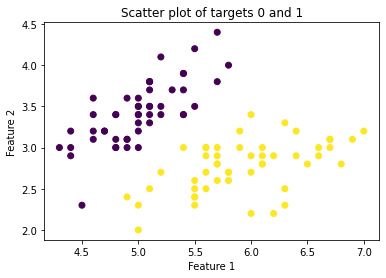

In [10]:
import matplotlib.pyplot as plt 

plt.scatter(X2_binary[:, 0], X2_binary[:, 1], c=y2_binary, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter plot of targets 0 and 1')
plt.show()


Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

In [13]:
C_list = [0.01, 0.1, 1, 10, 200]

for C in C_list:
    classifier = SVC(kernel='linear', C=C)
    classifier.fit(X_train2, y_train2)
    score = classifier.score(X_test2, y_test2)
    print(f"C={C}, Score={score}")



C=0.01, Score=0.4
C=0.1, Score=1.0
C=1, Score=1.0
C=10, Score=1.0
C=200, Score=1.0


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

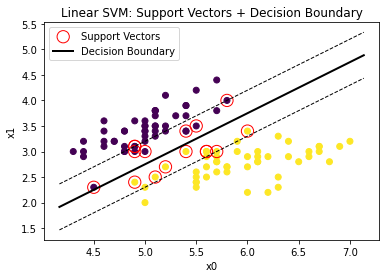

In [28]:
import numpy as np
supvectors=SVMmodel2.support_vectors_
# Plot the support vectors here
plt.scatter(X2_binary[:, 0], X2_binary[:, 1], c=y2_binary, cmap='viridis')
plt.scatter(supvectors[:, 0], supvectors[:, 1], s=150, facecolors='none', edgecolors='r', label='Support Vectors')

#Separating line coefficients:
W=SVMmodel2.coef_.ravel()
b=SVMmodel2.intercept_[0]

w0 ,w1 = W[0], W[1]
ax = plt.gca()
x_min, x_max = ax.get_xlim()
xx = np.linspace(x_min, x_max, 200)

eps = 1e-12
if abs(w1) > eps:
    yy = - (w0/w1) * xx - b/w1
    plt.plot(xx, yy, 'k-', linewidth=2, label='Decision Boundary')
    yy_m1 = -(w0 / w1) * xx - ((b - 1) / w1)
    yy_p1 = -(w0 / w1) * xx - ((b + 1) / w1)
    plt.plot(xx, yy_m1, 'k--', linewidth=1)
    plt.plot(xx, yy_p1, 'k--', linewidth=1)
else:
    x_vertical = -b / (w0 + eps)
    plt.axvline(x_vertical, color='k', linewidth=2, label='Decision boundary')

    plt.axvline((-b + 1) / (w0 + eps), color='k', linestyle='--', linewidth=1)
    plt.axvline((-b - 1) / (w0 + eps), color='k', linestyle='--', linewidth=1)

plt.legend()
plt.title("Linear SVM: Support Vectors + Decision Boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()




# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

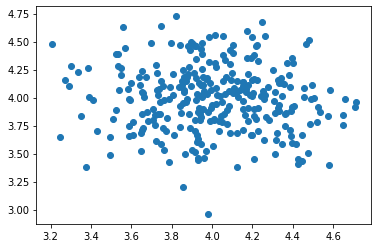

In [29]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

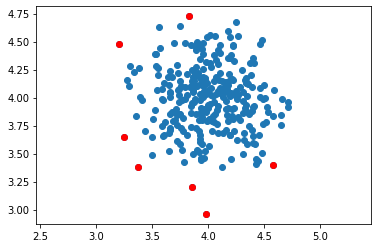

In [30]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

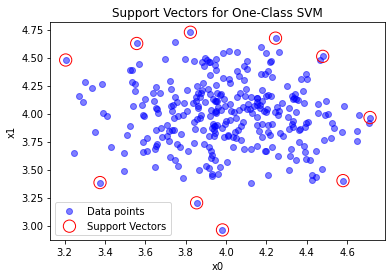

In [32]:
supvectors = SVMmodelOne.support_vectors_

plt.scatter(x[:, 0], x[:, 1], color='blue', alpha=0.5, label='Data points')
plt.scatter(supvectors[:, 0], supvectors[:, 1], s=150, facecolors='none', edgecolors='red', label='Support Vectors')
plt.legend()
plt.title("Support Vectors for One-Class SVM")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.989098620408397


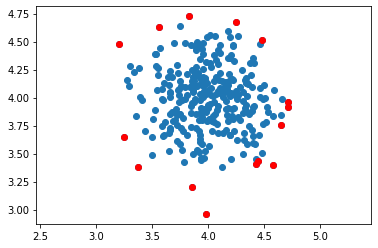

In [34]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.05)
print(thresh)
index = where(scores<=thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()